In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import joblib

sns.set(style="whitegrid")

In [2]:
rfm = pd.read_csv("../data/rfm.csv")
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [3]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df.head()


,PC1,PC2
0,4.106623,5.433579
1,0.742411,-0.671300
2,0.024802,-0.174954
3,-0.028036,-0.735124
4,-1.235466,1.834946


In [7]:
print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.55502102 0.30249315]


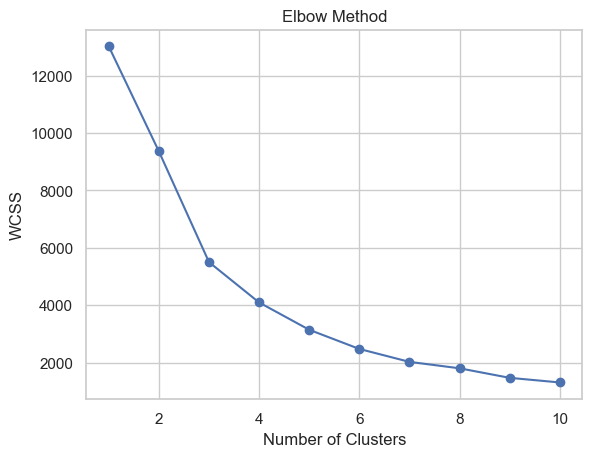

In [8]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

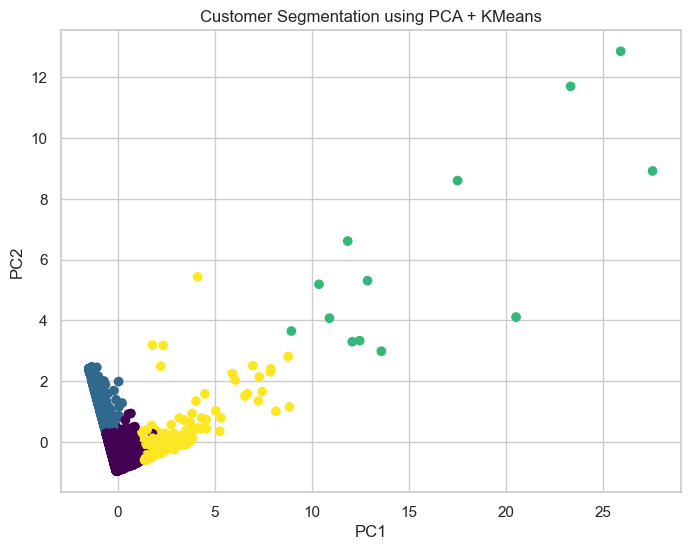

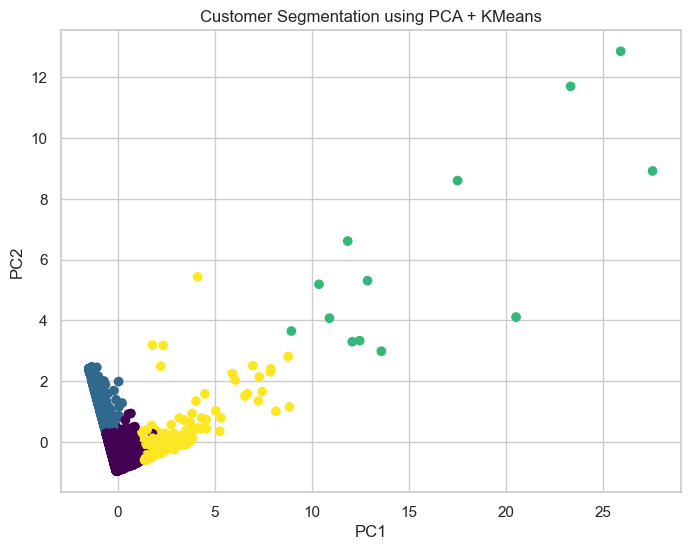

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=rfm['Cluster'], cmap='viridis')

plt.title("Customer Segmentation using PCA + KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=rfm['Cluster'], cmap='viridis')

plt.title("Customer Segmentation using PCA + KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [11]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


In [12]:
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(pca, "../models/pca.pkl")
joblib.dump(kmeans, "../models/kmeans.pkl")

['../models/kmeans.pkl']